In [2]:
import networkx as nx
import osmnx as ox

In [3]:
#downloading our chosen street network of Carmel, Indiana, USA
# through making a query in the form of a dict
place = {"city": "Carmel", "state": "Indiana", "country": "USA"}
G = ox.graph_from_place(place, network_type="drive", truncate_by_edge=True)

In [4]:
#calculating basic statistics for the street network, such as number of nodes, edges, average node degree etc.

In [5]:
#calculating number of nodes
print("The graph has", len(G.nodes), "nodes")

#calculating number of edges
print("The graph has", len(G.edges), "edges")

The graph has 6112 nodes
The graph has 13688 edges


In [6]:
#exploring the data type of nodes
print("The nodes are", print(type(G.nodes)))

<class 'networkx.classes.reportviews.NodeView'>
The nodes are None


In [7]:
#exploring the data type of edges
print("The edges are", print(type(list(G.edges(data=True))[0])))

<class 'tuple'>
The edges are None


In [8]:
#exploring elements of the first and last nodes
print(list(G.nodes(data=True))[0])
print(list(G.nodes(data=True))[-1])

(178882025, {'y': 39.9503101, 'x': -86.2407299, 'street_count': 3})
(12706681920, {'y': 39.9995797, 'x': -86.162231, 'street_count': 2})


In [9]:
#exploring elements of the first and last edges
print(list(G.edges(data=True))[0])
print(list(G.edges(data=True))[-1])

(178882025, 178882035, {'osmid': 17263174, 'highway': 'residential', 'name': 'Tillson Drive', 'oneway': False, 'reversed': False, 'length': np.float64(388.65363766939737), 'geometry': <LINESTRING (-86.241 39.95, -86.241 39.95, -86.241 39.95, -86.241 39.95, -86...>})
(12706681920, 179782043, {'osmid': 1178222798, 'highway': 'residential', 'oneway': True, 'reversed': False, 'length': np.float64(55.36129263604355), 'geometry': <LINESTRING (-86.162 40, -86.162 40, -86.162 40, -86.162 40, -86.162 40, -86...>})


In [10]:
#calculating average node degree 
#warning - very large cell output
nx.average_neighbor_degree(G, weight="weight")

{178882025: 2.3333333333333335,
 178882035: 3.0,
 178882486: 3.0,
 178884871: 2.5,
 178888794: 2.6666666666666665,
 179688996: 3.0,
 179689026: 2.6666666666666665,
 179689126: 2.3333333333333335,
 179689162: 3.0,
 179689209: 2.5,
 179689211: 2.3333333333333335,
 179689249: 2.3333333333333335,
 179689265: 3.3333333333333335,
 179689273: 2.0,
 179689276: 4.0,
 179689283: 3.25,
 179689291: 3.0,
 179689299: 2.3333333333333335,
 179689309: 2.3333333333333335,
 179689325: 2.3333333333333335,
 179689330: 2.3333333333333335,
 179689337: 2.3333333333333335,
 179689348: 2.3333333333333335,
 179689360: 3.0,
 179689372: 3.0,
 179689393: 3.0,
 179689408: 3.0,
 179689415: 3.0,
 179689443: 3.0,
 179689601: 3.0,
 179689614: 3.3333333333333335,
 179689618: 2.3333333333333335,
 179689635: 3.0,
 179690209: 3.0,
 179690211: 3.0,
 179690254: 4.0,
 179690256: 2.3333333333333335,
 179690257: 3.0,
 179690368: 4.0,
 179690465: 2.3333333333333335,
 179690555: 2.3333333333333335,
 179690558: 3.0,
 179690585: 3.0

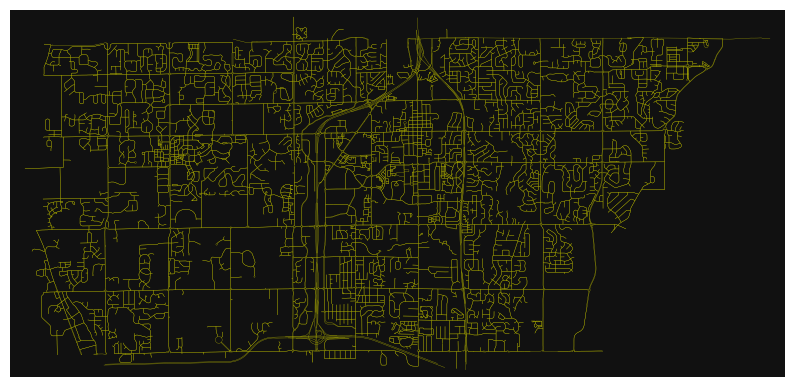

In [11]:
#plotting street network using OSMnx
fig, ax = ox.plot_graph(G, figsize=(10, 10), node_size=0, edge_color="y", edge_linewidth=0.2)

In [ ]:
#customising the node size and edge color

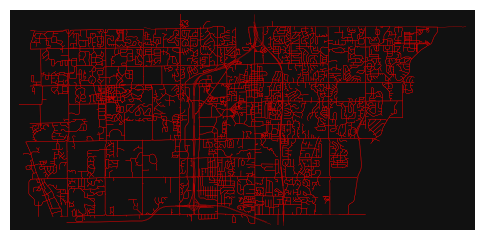

In [12]:
#first experiment, changing the color and figure size
fig, ax = ox.plot_graph(G, figsize=(6, 6), node_size=0, edge_color="r", edge_linewidth=0.2)

In [ ]:
#second experiment, visualising street centrality using color
#defining edge centrality and ev
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
ev = [edge_centrality[edge + (0,)] for edge in G.edges()]

#converting the color scale to a list of colors for graph edges
norm = colors.Normalize(vmin=min(ev)*0.8, vmax=max(ev))
cmap = cm.ScalarMappable(norm=norm, cmap=cm.inferno)
ec = [cmap.to_rgba(cl) for cl in ev]

# coloring the edges with closeness centralities in the line graph
fig, ax = ox.plot_graph(G, bgcolor='k', axis_off=True, node_size=0,
                        edge_color=ec, edge_linewidth=1.5, edge_alpha=1)

Reference: gboeing (2017). osmnx-examples/notebooks/00-osmnx-features-demo.ipynb at v0.13.0 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.13.0/notebooks/00-osmnx-features-demo.ipynb [Accessed 16 Mar. 2025].

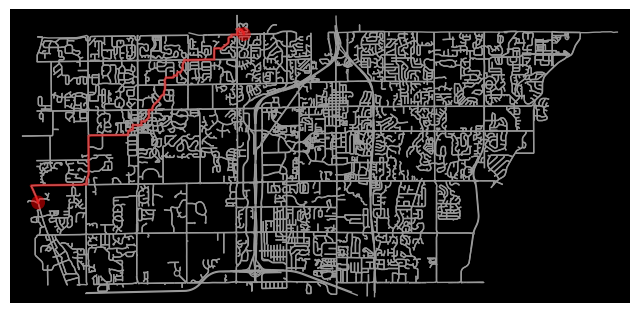

In [14]:
#utilise the routing capabilities of OSMnx to find the shortest path between two points 

#establishing origin
orig = list(G)[0]

#establishing destination
dest = list(G)[-1]

#plot the route
route = nx.shortest_path(G, orig, dest, weight='length')
fig, ax = ox.plot_graph_route(G, route, route_linewidth=2, node_size=0, bgcolor='k')

Reference: Geoff Boeing. (2016). OSMnx: Python for Street Networks. [online] Available at: https://geoffboeing.com/2016/11/osmnx-python-street-networks/.

In [ ]:
#calculating centrality measures
#calculating degree centrality
degree_centrality = nx.degree_centrality(G)
for node, centrality in degree_centrality.items():
    print(f"Node {node}: Degree Centrality = {centrality: .3f}")
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue')
plt.title('Graph G with Degree Centrality')
plt.show()

#calculating betweenness centrality
extended_stats = ox.extended_stats(G, bc=True)
print(extended_stats['betweenness_centrality_avg'])

Node 178882025: Degree Centrality =  0.001
Node 178882035: Degree Centrality =  0.000
Node 178882486: Degree Centrality =  0.000
Node 178884871: Degree Centrality =  0.001
Node 178888794: Degree Centrality =  0.001
Node 179688996: Degree Centrality =  0.001
Node 179689026: Degree Centrality =  0.001
Node 179689126: Degree Centrality =  0.001
Node 179689162: Degree Centrality =  0.000
Node 179689209: Degree Centrality =  0.001
Node 179689211: Degree Centrality =  0.001
Node 179689249: Degree Centrality =  0.001
Node 179689265: Degree Centrality =  0.001
Node 179689273: Degree Centrality =  0.001
Node 179689276: Degree Centrality =  0.000
Node 179689283: Degree Centrality =  0.001
Node 179689291: Degree Centrality =  0.001
Node 179689299: Degree Centrality =  0.001
Node 179689309: Degree Centrality =  0.001
Node 179689325: Degree Centrality =  0.001
Node 179689330: Degree Centrality =  0.001
Node 179689337: Degree Centrality =  0.001
Node 179689348: Degree Centrality =  0.001
Node 179689

In [ ]:
#creating figure-ground diagram from San Diego
import osmnx as ox
from IPython.display import Image

#configuring the inline image display
img_folder = "images"
extension = "png"
size = 240
dpi = 40

#picking a point in Carmel to display
place = 'Carmel'
point=(39.9503101, -86.2407299)
fig, ax = ox.plot_figure_ground(point=point, filename=place, dpi=dpi)
Image('{}/{}.{}'.format(img_folder, place, extension), height=size, width=size)

Reference: gboeing (2017). osmnx-examples/notebooks/09-example-figure-ground.ipynb at v0.11 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.11/notebooks/09-example-figure-ground.ipynb [Accessed 16 Mar. 2025].

In [ ]:
#creating interactive maps to plot nodes, edges, nodes+edges and one of centrality measures

In [ ]:
warnings.filterwarnings('ignore')
# downloading a street network then solve a shortest-path route on it
weight = "length"
G = ox.graph_from_place("Westfield Blvd, Carmel", network_type="drive")
orig = list(G.nodes)[0]
dest = list(G.nodes)[-1]
route = ox.shortest_path(G, orig, dest, weight=weight)

In [ ]:
# exploring graph edges interactively, with a simple one-liner
ox.graph_to_gdfs(G, nodes=False).explore()

In [ ]:
# exploring graph nodes interactively, with different basemap tiles
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.explore(tiles="cartodbpositron", marker_kwds={"radius": 8})

In [ ]:
# exploring nodes and edges together in a single map
nodes, edges = ox.graph_to_gdfs(G)
m = edges.explore(color="skyblue", tiles="cartodbdarkmatter")
nodes.explore(m=m, color="pink", marker_kwds={"radius": 6})

In [ ]:
# exploring graph edges interactively, colored by length
edges.explore(tiles="cartodbdarkmatter", column="length", cmap="plasma")

In [ ]:
# exploring graph nodes interactively, colored by betweenness centrality
nx.set_node_attributes(G, nx.betweenness_centrality(G, weight="length"), name="bc")
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.explore(tiles="cartodbdarkmatter", column="bc", marker_kwds={"radius": 8})

In [ ]:
#exporting street network to a geopackage file
x.save_graph_geopackage(G, filepath="./data/mynetwork.gpkg")
ox.save_graphml(G, filepath="./data/mynetwork.graphml")

In [ ]:
#reading the geopackage file in python
read = "./data/mynetwork.gpkg"

In [ ]:
#using OSMnx to extract other urban elements e.g. buildings, parks and plotting them
osmnx.features.features_from_address(str, building, float)